# Act 3 - Scenario simulation nếu cắt promo âm

**Câu hỏi trung tâm:** Nếu cắt các promotion có GP contribution âm, kết quả tài chính thay đổi thế nào dưới các giả định demand recapture khác nhau?

Act này vẫn giữ forecast tuyến tính như risk context, nhưng phần quyết định chính là scenario simulation. Đây là phần predictive thực dụng hơn cho CEO.


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / "outputs").exists() and (ROOT.parent / "outputs").exists():
    ROOT = ROOT.parent
CHARTS = ROOT / "outputs" / "charts"
TABLES = ROOT / "outputs" / "tables"


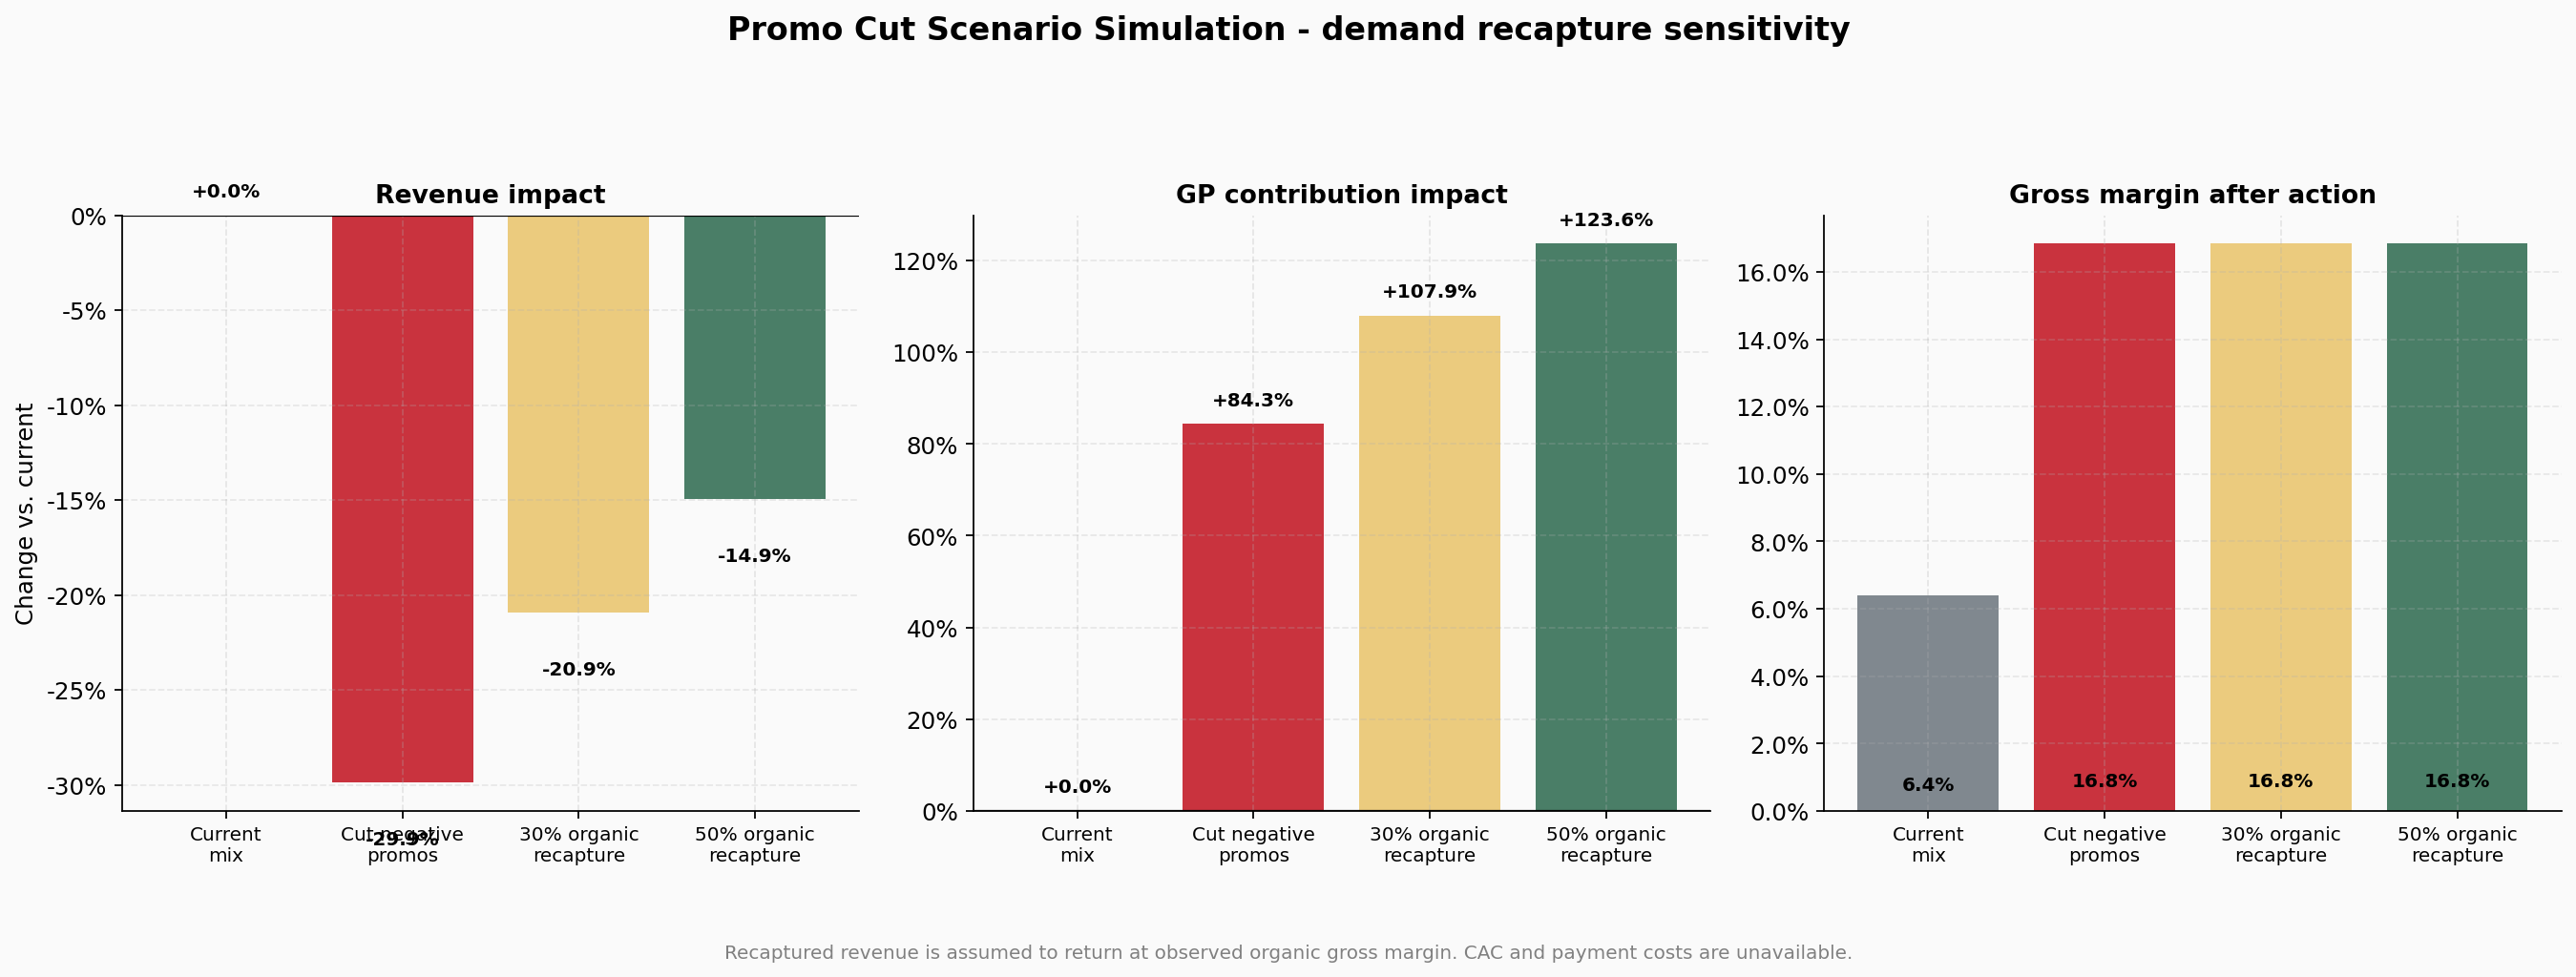

In [2]:
display(Image(str(CHARTS / "chart5_margin_scenario_simulation.png"), width=950))


In [3]:
scenario = pd.read_csv(TABLES / "promo_cut_scenario_table.csv")
display(scenario)
forecast = pd.read_csv(TABLES / "margin_forecast_table.csv")
display(forecast[forecast["quarter"].isin(["2026Q4", "2027Q4"])])


,scenario,recapture_rate,revenue,gp_contribution,gross_margin,revenue_impact_pct,gp_impact_pct,assumption
0,Current mix,NaN,1.568087e+10,1.004011e+09,0.064028,0.000000,0.000000,All promotions continue
1,Cut negative promos,0.0,1.099504e+10,1.850890e+09,0.168339,-29.882465,84.349626,0% of removed promo revenue returns at organic...
2,Cut + 30% organic recapture,0.3,1.240079e+10,2.087532e+09,0.168339,-20.917725,107.919284,30% of removed promo revenue returns at organi...
3,Cut + 50% organic recapture,0.5,1.333795e+10,2.245294e+09,0.168339,-14.941232,123.632390,50% of removed promo revenue returns at organi...


,quarter,date,forecast,lower_1sd,upper_1sd
15,2026Q4,2026-10-01,-0.129175,-8.979894,8.721543
19,2027Q4,2027-10-01,-0.691601,-9.542319,8.159118


## Phân tích

Baseline hiện tại tạo **15,680,869,265 VND revenue**, **1,004,010,930 VND GP contribution sau refund và shipping**, tương ứng gross margin **6.4%**.

Trong worst case **0% demand recapture**, cắt **50 negative-GP promotions** làm revenue giảm còn **10,995,039,053 VND** (**-29.9%**), nhưng GP contribution tăng lên **1,850,890,392 VND** (**+84.3%**) và gross margin tăng lên **16.8%**.

Nếu **30% lost promo revenue được recapture ở organic margin**, revenue còn **12,400,788,117 VND** (**-20.9%**) và GP contribution tăng **+107.9%**. Với **50% recapture**, revenue còn **13,337,954,159 VND** (**-14.9%**) và GP contribution tăng **+123.6%**.

Linear forecast chỉ là cảnh báo rủi ro, không phải decision rule. Trend gần đây giảm khoảng **0.1 điểm %/quý**, last-four-quarter margin chỉ **4.4%**. Forecast **2026 Q4 là -0.1%** với range **-9.0% đến 8.7%**; **2027 Q4 là -0.7%** với range **-9.5% đến 8.2%**. Range quá rộng nên không đủ để ra quyết định một mình.

**Kết luận Act 3:** Scenario simulation là bằng chứng predictive chính: cắt promo âm vẫn cải thiện GP ngay cả khi không có demand recapture.
